In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("D:/netflix data analysis/netflix_titles.csv")

# Display first 5 rows
df.head()
# Number of rows and columns
print(df.shape)

# Column names
print(df.columns)

# Dataset information
df.info()
# Statistical summary
df.describe(include='all')
# Check missing values
print(df.isnull().sum())

In [ ]:
#Data cleaning
# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print("Duplicates:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['date_added'] = df['date_added'].fillna('')

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(
    df['date_added'], errors='coerce'
)

# Check missing values again
print(df.isnull().sum())

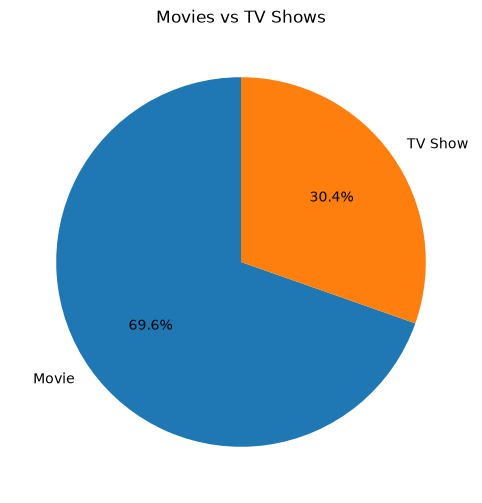

In [11]:
#Movies vs TV Shows
# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    content_counts,
    labels=content_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Movies vs TV Shows")
plt.show()

In [ ]:
#Top 10 countries with the most content
# Split countries because some rows contain multiple countries
countries = df['country'].str.split(', ').explode()

# Remove Unknown
countries = countries[countries != 'Unknown']

# Find top 10 countries
top_countries = countries.value_counts().head(10)

print(top_countries)

# Plot bar chart using Matplotlib
plt.figure(figsize=(12, 6))

plt.bar(
    top_countries.index,
    top_countries.values
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Content added over the years
# Extract year from date_added
df['year_added'] = df['date_added'].dt.year

# Count titles by year
yearly_content = df['year_added'].value_counts().sort_index()

# Plot line chart using Matplotlib
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_content.index,
    yearly_content.values,
    marker='o',
    linestyle='-'
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)
plt.tight_layout()
plt.show()

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
show_id            0
type               0
title              0
director        2634
cast         

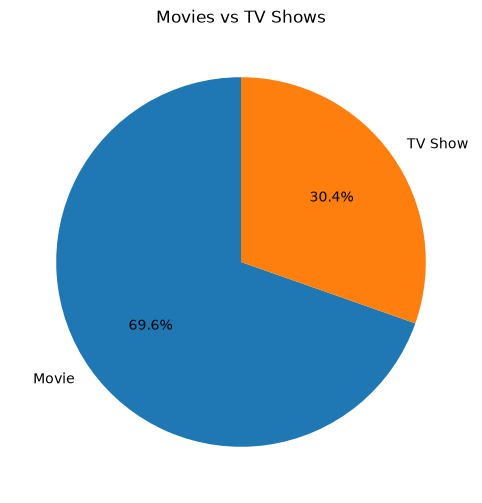

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


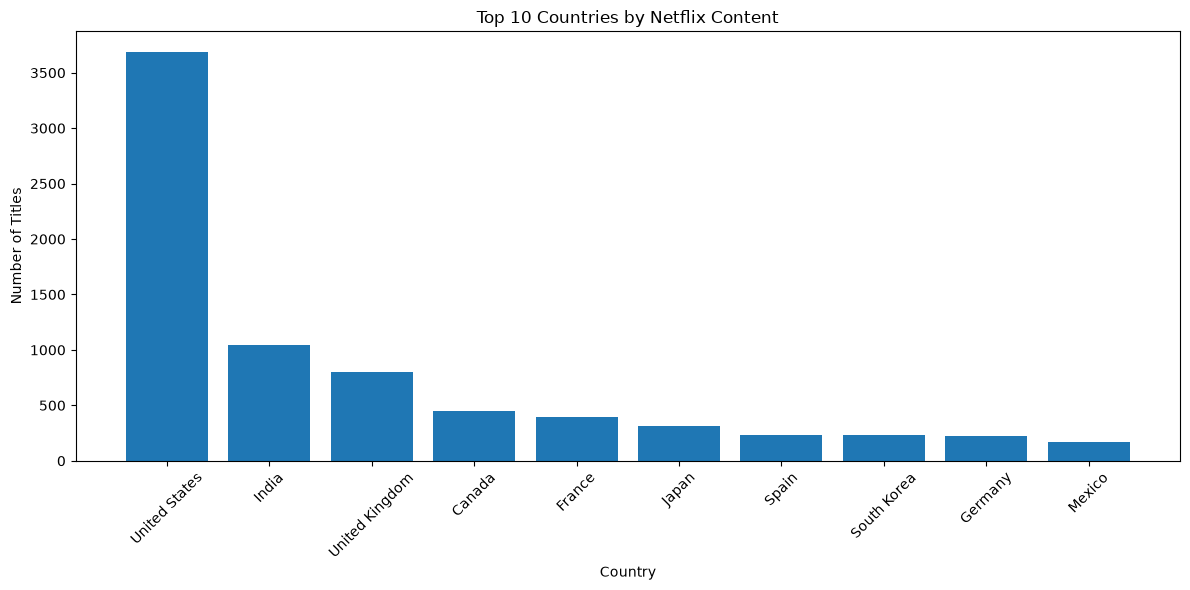

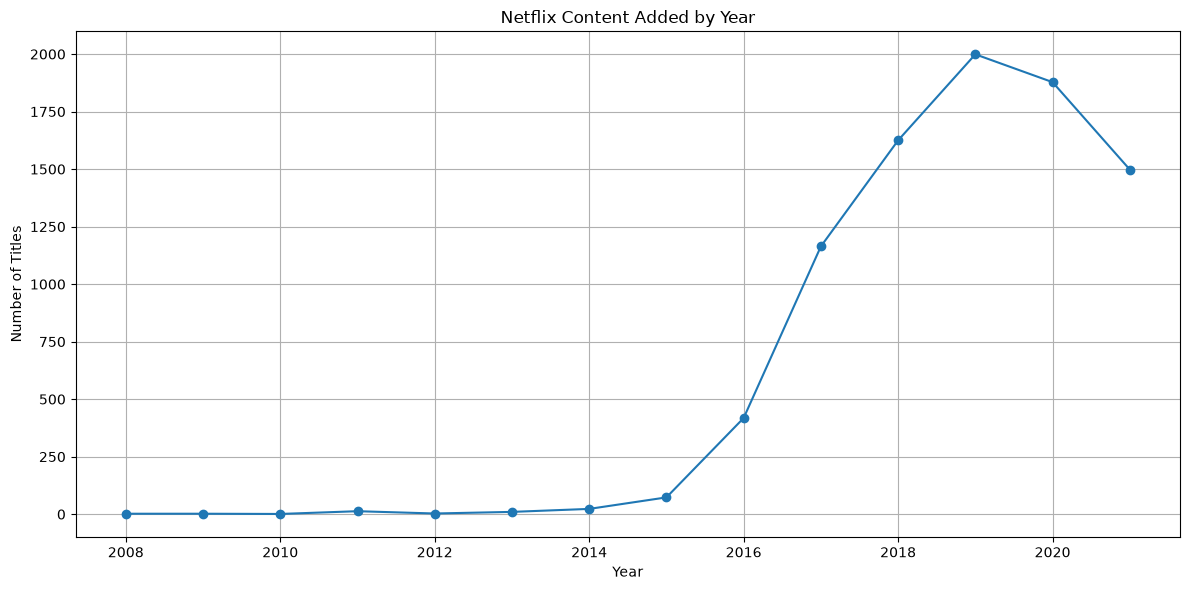

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64


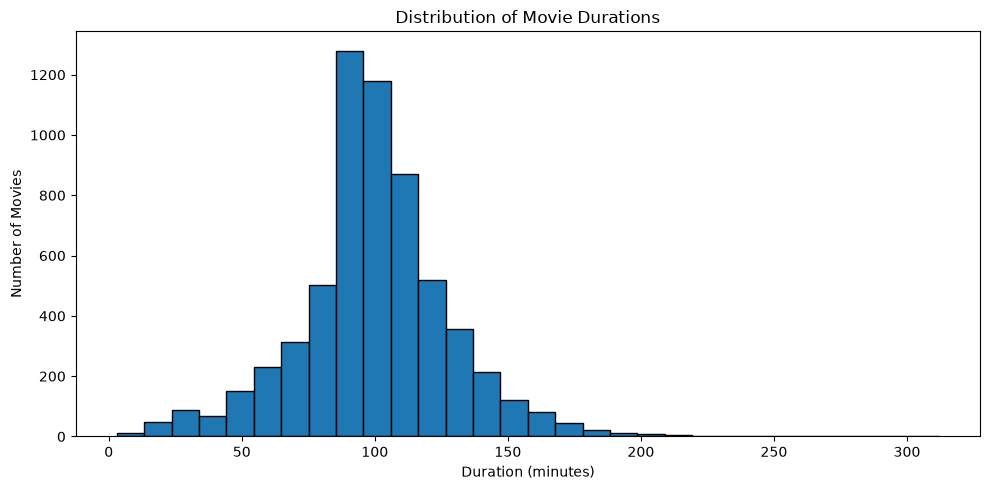

In [9]:

#Analyze movie durations
# Filter movies only
movies = df[df['type'] == 'Movie'].copy()

# Extract duration in minutes
movies['duration_minutes'] = (
    movies['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

# Summary statistics
print(movies['duration_minutes'].describe())

# Histogram using Matplotlib
plt.figure(figsize=(10, 5))

plt.hist(
    movies['duration_minutes'].dropna(),
    bins=30,
    edgecolor='black'
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

seasons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64


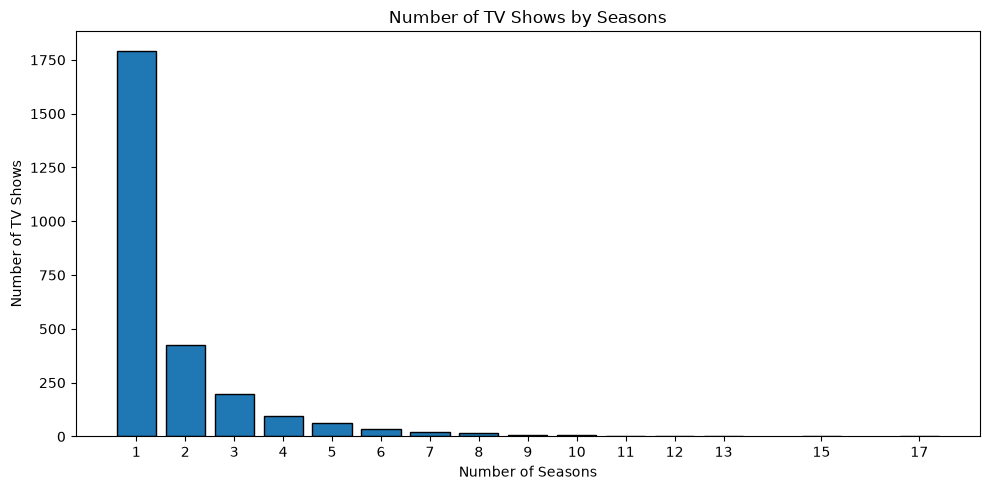

In [10]:
# Filter TV shows
tv_shows = df[df['type'] == 'TV Show'].copy()

# Extract season count
tv_shows['seasons'] = (
    tv_shows['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

# Count TV shows by seasons
season_counts = tv_shows['seasons'].value_counts().sort_index()

print(season_counts)

# Plot using Matplotlib
plt.figure(figsize=(10, 5))

plt.bar(
    season_counts.index,
    season_counts.values,
    edgecolor='black'
)

plt.title("Number of TV Shows by Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.xticks(season_counts.index)

plt.tight_layout()
plt.show()

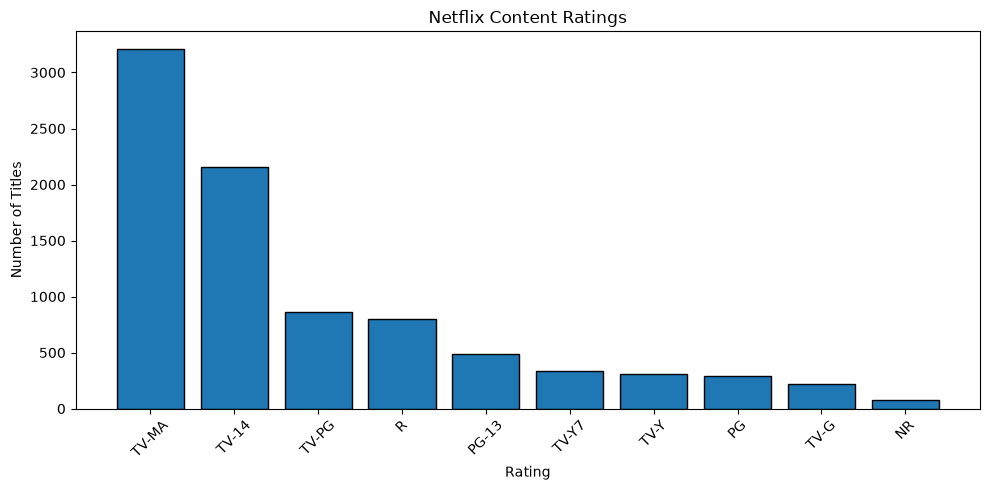

In [12]:
#Content ratings analysis
# Count top 10 ratings
rating_counts = df['rating'].value_counts().head(10)

# Plot bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    rating_counts.index,
    rating_counts.values,
    edgecolor='black'
)

plt.title("Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

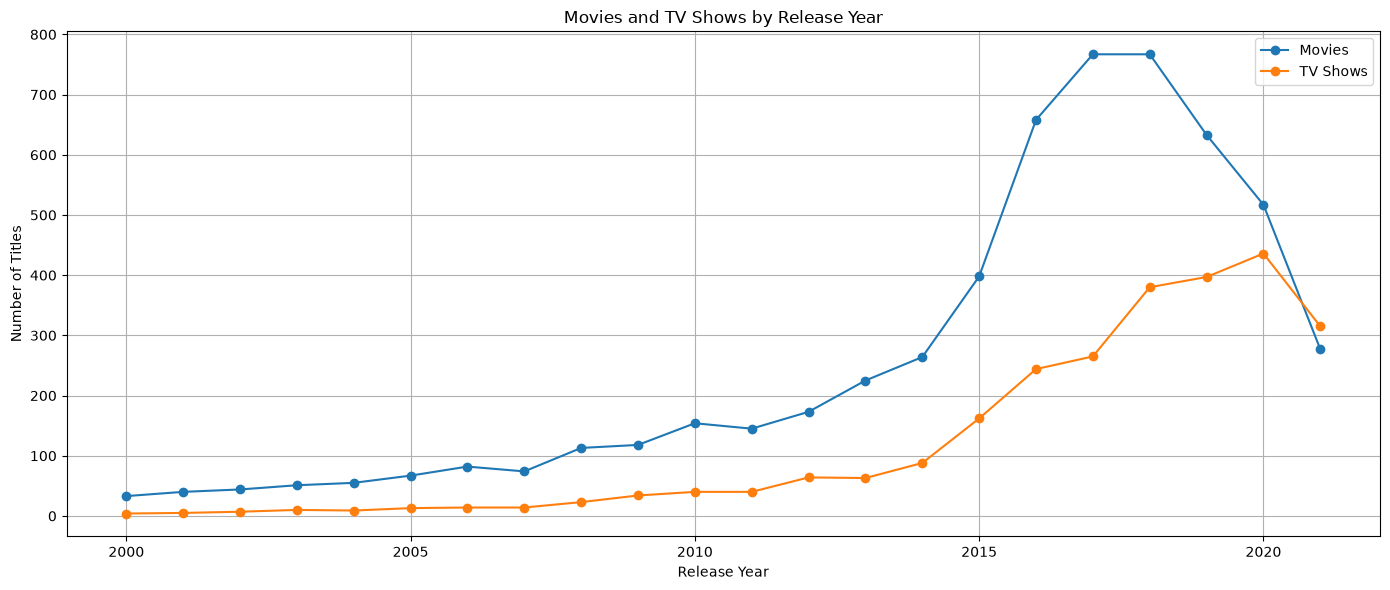

In [13]:
#Movies and TV shows released each year
# Group data by release year and type
release_data = df.groupby(
    ['release_year', 'type']
).size().reset_index(name='count')

# Select years from 2000 to 2021
release_data = release_data[
    (release_data['release_year'] >= 2000) &
    (release_data['release_year'] <= 2021)
]

# Separate movies and TV shows
movies = release_data[release_data['type'] == 'Movie']
tv_shows = release_data[release_data['type'] == 'TV Show']

# Plot line chart
plt.figure(figsize=(14, 6))

plt.plot(
    movies['release_year'],
    movies['count'],
    marker='o',
    label='Movies'
)

plt.plot(
    tv_shows['release_year'],
    tv_shows['count'],
    marker='o',
    label='TV Shows'
)

plt.title("Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
#Final insights
# Total titles
print("Total Titles:", len(df))

# Movies and TV Shows
print("\nMovies and TV Shows:")
print(df['type'].value_counts())

# Most common rating
print("\nMost Common Rating:")
print(df['rating'].mode()[0])

# Most common release year
print("\nMost Common Release Year:")
print(df['release_year'].mode()[0])

# Top 5 countries
print("\nTop 5 Countries:")
print(top_countries.head())

# Top 5 genres
print("\nTop 5 Genres:")
print(top_genres.head())

# Average movie duration
print("\nAverage Movie Duration:")
print(round(movies['duration_minutes'].mean(), 2), "minutes")

Total Titles: 8807

Movies and TV Shows:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Most Common Rating:
TV-MA

Most Common Release Year:
2018

Top 5 Countries:
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64

Top 5 Genres:


NameError: name 'top_genres' is not defined